In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer

import re
import string

In [2]:
df=pd.read_excel(r"E:\Data Science classes\project\NLP Sentiment Analysis\dataset -P684.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (1440, 3)


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [4]:
print("Missing Values :",df.isnull().sum())
print('Duplicate Values',df.duplicated().sum())

Missing Values : title     0
rating    0
body      0
dtype: int64
Duplicate Values 0


In [5]:
def map_sentiment(rating):
    if rating >= 4: return "Positive"
    elif rating <= 2: return "Negative"
    else: return "Neutral"

df['Sentiment'] = df['rating'].apply(map_sentiment)
df.head()

,title,rating,body,Sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative


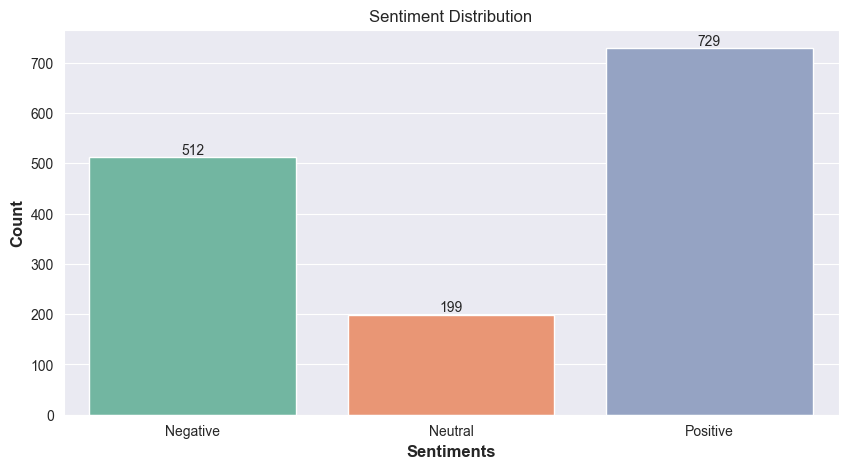

In [6]:
plt.figure(figsize = (10,5))
ax=sns.countplot(x='Sentiment', data=df, hue='Sentiment', palette='Set2')
plt.title('Sentiment Distribution')
for count in ax.containers:
    ax.bar_label(count)
plt.xlabel('Sentiments', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.show()

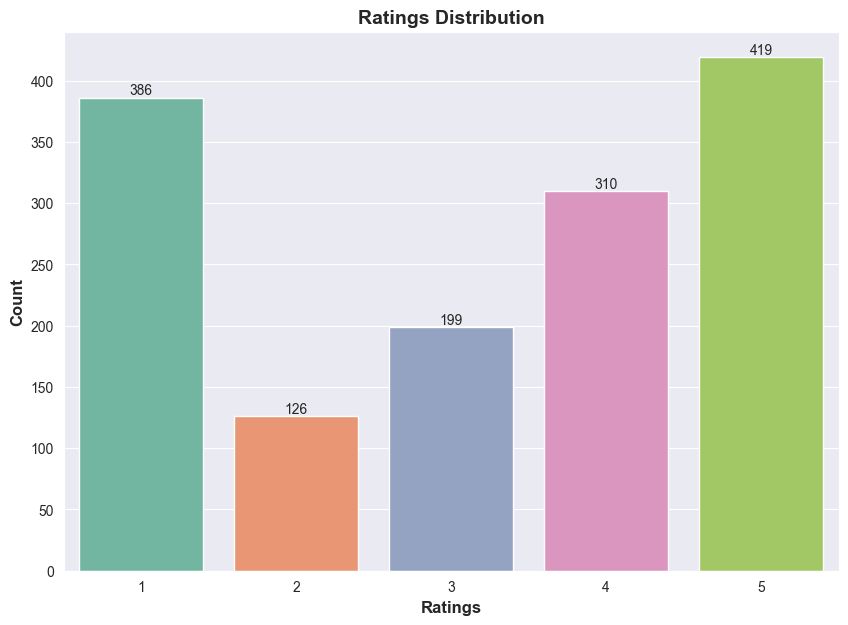

In [7]:
plt.figure(figsize = (10,7))
ax=sns.countplot(data=df, x='rating', palette='Set2')
plt.title('Ratings Distribution', fontsize = 14, fontweight = 'bold')
for count in ax.containers:
    ax.bar_label(count)
plt.xlabel('Ratings', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.show()

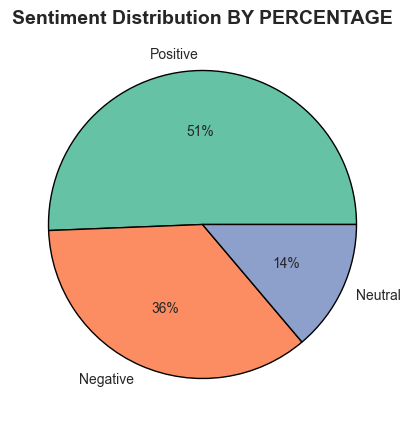

In [8]:
sentiment_count = df['Sentiment'].value_counts()

plt.figure(figsize = (6,5))
ax= plt.pie(x=sentiment_count, labels=sentiment_count.index, autopct='%1.0f%%', colors= sns.color_palette('Set2'), wedgeprops={'edgecolor':"black"})
plt.title('Sentiment Distribution BY PERCENTAGE', fontsize = 14, fontweight = 'bold')
plt.show()

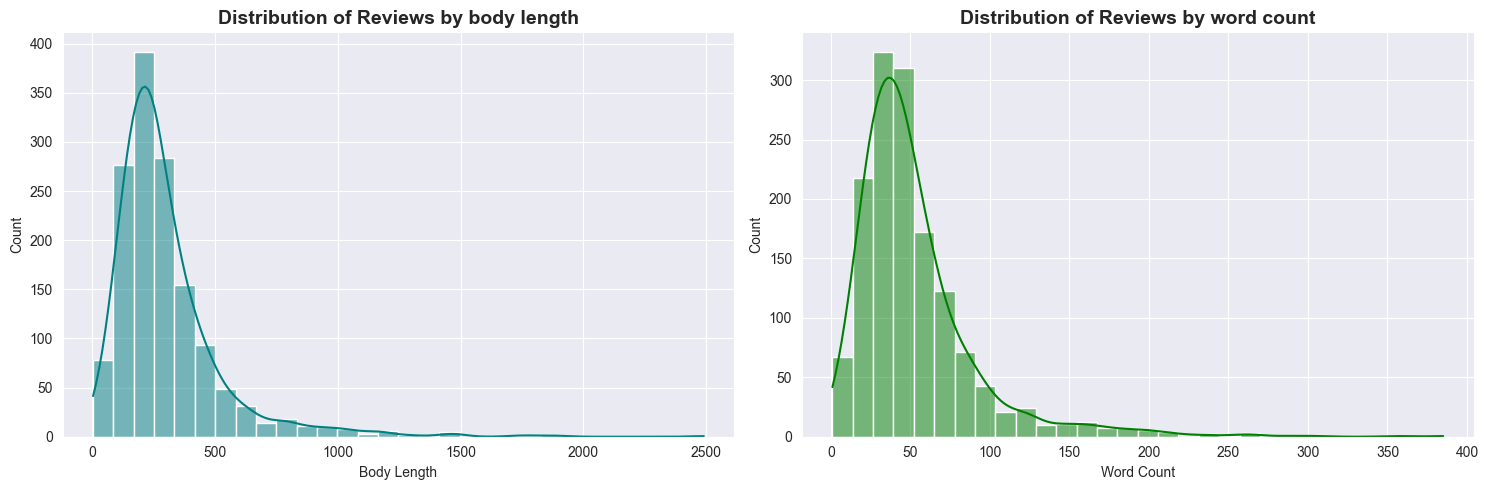

,count,mean,std,min,25%,50%,75%,max
body_length,1440.0,302.109028,225.733052,4.0,170.0,246.0,359.00,2490.0
word_count,1440.0,52.892361,39.346259,1.0,29.0,43.0,63.25,385.0


In [9]:
df['body_length'] = df['body'].astype(str).apply(len)
df['title_length'] = df['title'].astype(str).apply(len)
df['word_count'] = df['body'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1,2,figsize=(15,5))
sns.histplot(df['body_length'],bins=30,kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Reviews by body length', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Body Length')
axes[0].set_ylabel('Count')


sns.histplot(df['word_count'],bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Reviews by word count', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

df[['body_length','word_count']].describe().T

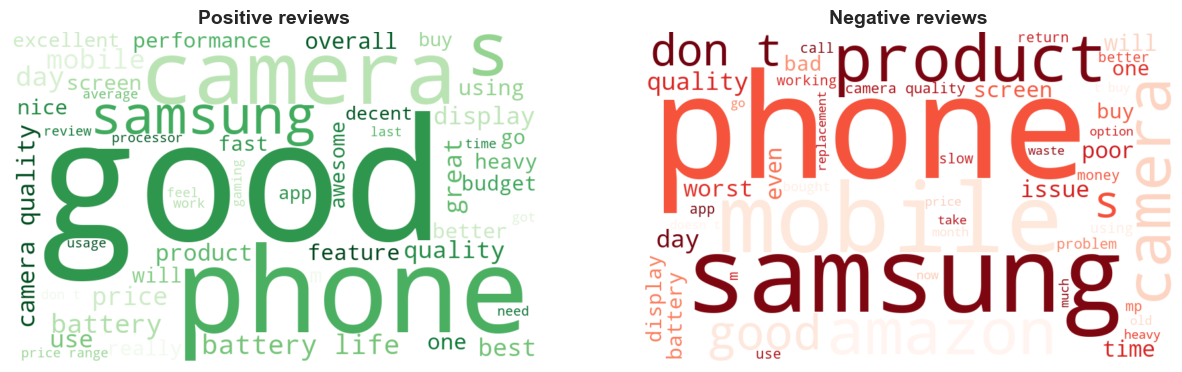

In [10]:
from wordcloud import wordcloud, WordCloud


def clean_text_wc(text):
    text=str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text

pos_text = ''.join(df[df['rating']>=4]['body'].apply(clean_text_wc))
neg_text = ''.join(df[df['rating']<=2]['body'].apply(clean_text_wc))

fig, axes = plt.subplots(1,2,figsize=(15,5))
wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens',max_words=50).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive reviews', fontsize = 14, fontweight = 'bold')

neg_wc=WordCloud(width=800, height=500, background_color='white', colormap='Reds',max_words=50).generate(neg_text)
axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative reviews', fontsize = 14, fontweight = 'bold')

plt.show()


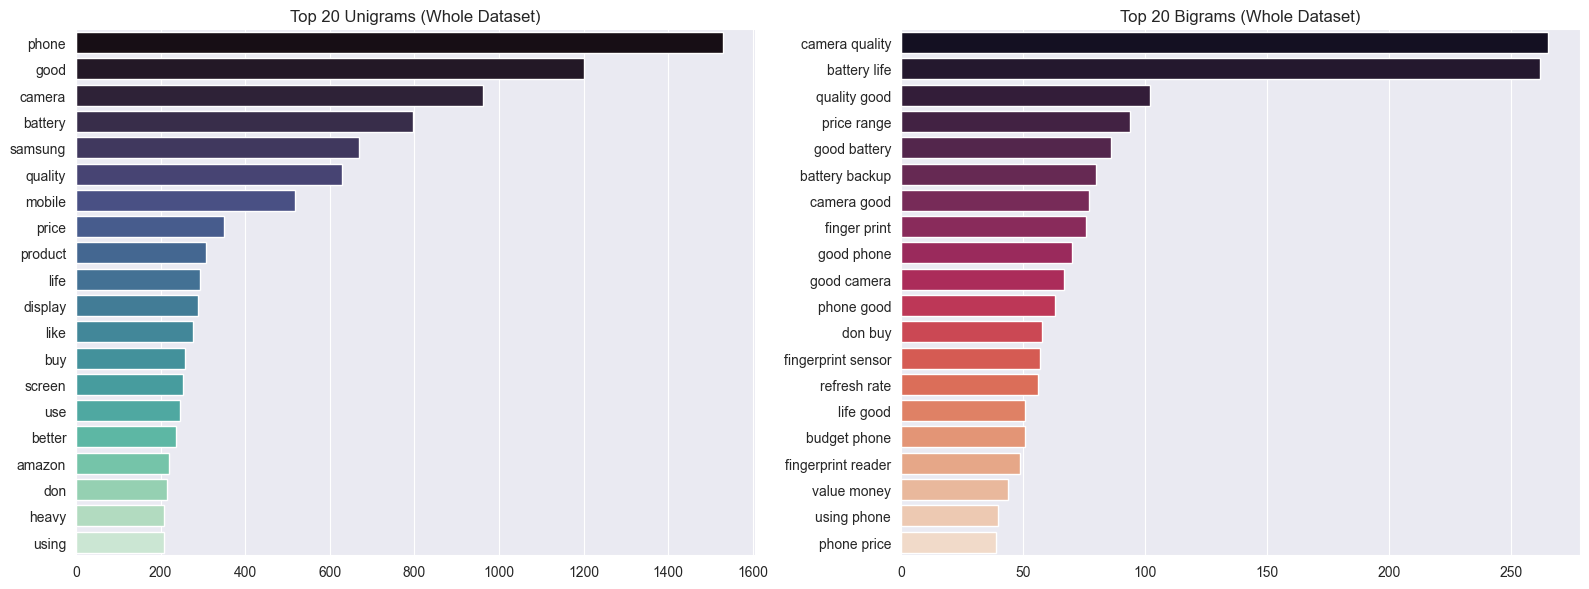

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=20, ngram_range=(1,1)):
    vec=CountVectorizer(ngram_range=ngram_range, stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{2,}\b').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_of_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_of_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_unigrams = get_top_ngrams(df['body'].astype(str), 20, (1,1))
top_bigrams = get_top_ngrams(df['body'].astype(str), 20, (2,2))

fig, axes = plt.subplots(1, 2, figsize=(16,6))
u_words, u_counts = zip(*top_unigrams)
sns.barplot(x=list(u_counts), y=list(u_words), ax=axes[0], palette='mako')
axes[0].set_title('Top 20 Unigrams (Whole Dataset)')


b_words, b_counts = zip(*top_bigrams)
sns.barplot(x=list(b_counts), y=list(b_words), ax=axes[1], palette='rocket')
axes[1].set_title('Top 20 Bigrams (Whole Dataset)')
plt.tight_layout()
plt.show()

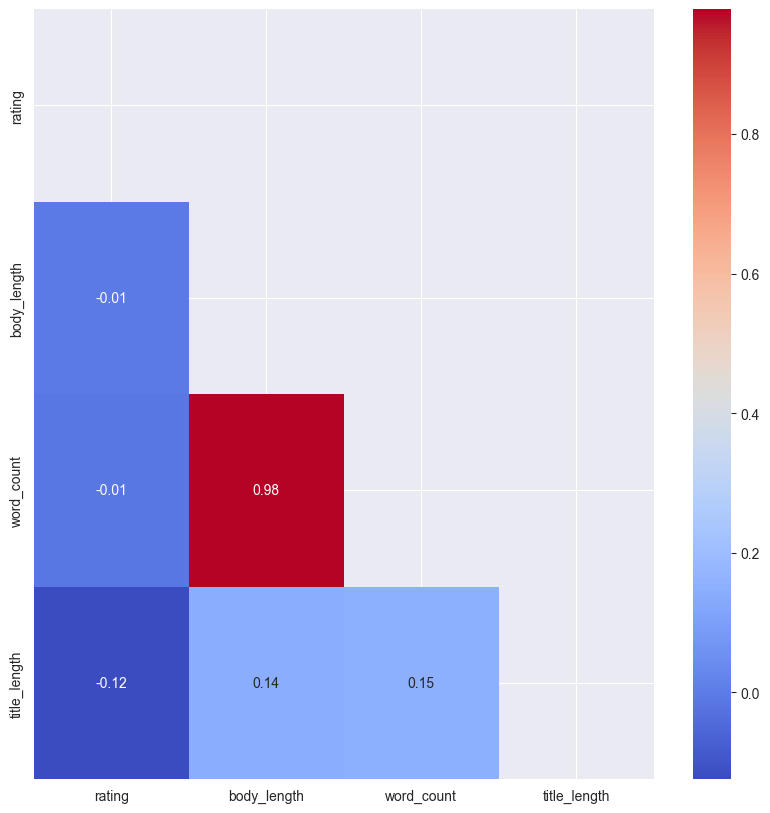

In [12]:
corr_matrix = df[['rating','body_length','word_count', 'title_length']].corr()
plt.figure(figsize = (10,10))
mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',mask=mask, fmt='.2f')
plt.show()

Text Preprocessing

In [13]:
def clean_text(text):
    text=str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


stop_words=set(stopwords.words('english'))
df['clean_body']=df['body'].apply(clean_text)
df['clean_title']=df['title'].apply(clean_text)
df['full_text']=df['clean_title'].apply(clean_text) + " " + df['clean_body'].apply(clean_text)
df['tokens'] = df['full_text'].apply(
    lambda x: [word for word in x.split() if word not in stop_words]
)


df[['clean_title','clean_body','full_text','tokens']].head()

,clean_title,clean_body,full_text,tokens
0,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...,"[horrible, product, disappointed, overall, per..."
1,camera quality is not like megapixel,camera quality is low,camera quality is not like megapixel camera qu...,"[camera, quality, like, megapixel, camera, qua..."
2,overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...,"[overall, got, mobile, launch, date, battery, ..."
3,a big no from me,it doesn t work with ghz wifi frequency ghz is...,a big no from me it doesn t work with ghz wifi...,"[big, work, ghz, wifi, frequency, ghz, old, sc..."
4,put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...,"[put, money, somewhere, else, worth, buying, f..."


In [14]:
#Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [15]:
df['clean_review'] = df['tokens'].apply(lambda words: " ".join(words))

df[['clean_review']].head()

,clean_review
0,horrible product disappointed overall performa...
1,camera quality like megapixel camera quality low
2,overall got mobile launch date battery must ap...
3,big work ghz wifi frequency ghz old school cam...
4,put money somewhere else worth buying faulty s...


In [16]:
df.drop(columns='tokens', inplace=True)

df.head()

,title,rating,body,Sentiment,body_length,title_length,word_count,clean_body,clean_title,full_text,clean_review
0,Horrible product,1,Very disappointed with the overall performance...,Negative,59,16,8,very disappointed with the overall performance...,horrible product,horrible product very disappointed with the ov...,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,21,39,4,camera quality is low,camera quality is not like megapixel,camera quality is not like megapixel camera qu...,camera quality like megapixel camera quality low
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,403,7,66,got the mobile on the launch date battery must...,overall,overall got the mobile on the launch date batt...,overall got mobile launch date battery must ap...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,377,16,67,it doesn t work with ghz wifi frequency ghz is...,a big no from me,a big no from me it doesn t work with ghz wifi...,big work ghz wifi frequency ghz old school cam...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,179,29,29,not worth buying faulty software poor display ...,put your money somewhere else,put your money somewhere else not worth buying...,put money somewhere else worth buying faulty s...


In [17]:
x = df['clean_review']
y=df['Sentiment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(x_train.shape, y_train.shape)

(1152,) (1152,)


In [18]:
tfidf=TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

print("TF-IDF train shape:", x_train_tfidf.shape)
print("TF-IDF test shape:", x_test_tfidf.shape)

TF-IDF train shape: (1152, 5000)
TF-IDF test shape: (288, 5000)


Models Building

In [19]:
models= {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM' : LinearSVC(class_weight='balanced',random_state=42),
    'Naive Bayes' : MultinomialNB(),
    'Random Forest' : RandomForestClassifier(n_estimators=200, class_weight='balanced'),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42, max_depth=3, subsample=0.8)
}

results = {}

for name, model in models.items():
    model.fit(x_train_tfidf, y_train)
    y_pred = model.predict(x_test_tfidf)
    acc=accuracy_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred, average='weighted')
    results[name] = {"model":model, "accuracy":acc, "f1":f1, "y_pred":y_pred}
    print(f"---- {name} ----")
    print(f"Accuracy Score: {acc:.4f}, Weighted F1 score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print()

---- Logistic Regression ----
Accuracy Score: 0.7396, Weighted F1 score: 0.7328
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.79       102
     Neutral       0.27      0.23      0.25        40
    Positive       0.82      0.83      0.82       146

    accuracy                           0.74       288
   macro avg       0.62      0.62      0.62       288
weighted avg       0.73      0.74      0.73       288


---- Linear SVM ----
Accuracy Score: 0.7500, Weighted F1 score: 0.7307
              precision    recall  f1-score   support

    Negative       0.76      0.83      0.79       102
     Neutral       0.27      0.15      0.19        40
    Positive       0.81      0.86      0.83       146

    accuracy                           0.75       288
   macro avg       0.61      0.61      0.61       288
weighted avg       0.72      0.75      0.73       288


---- Naive Bayes ----
Accuracy Score: 0.7535, Weighted F1 score: 0.6947
             

Models Evaluation

In [20]:
eval_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'weighted_F1': [results[m]['f1'] for m in results],
})
eval_df = eval_df.sort_values('weighted_F1', ascending=False).reset_index(drop=True)
eval_df

,Model,Accuracy,weighted_F1
0,Logistic Regression,0.739583,0.732827
1,Linear SVM,0.750000,0.730683
2,Gradient Boosting,0.760417,0.722154
3,Random Forest,0.767361,0.718281
4,Naive Bayes,0.753472,0.694682


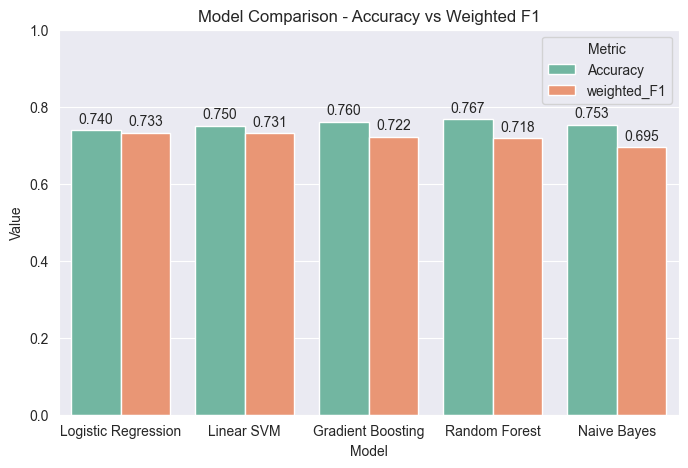

In [21]:
plt.figure(figsize = (8,5))
comp_melt= eval_df.melt(id_vars='Model', value_vars=['Accuracy', 'weighted_F1'], var_name='Metric', value_name='Value')
ax=sns.barplot(data=comp_melt, x='Model', y='Value', hue='Metric', palette='Set2')
for count in ax.containers:
    ax.bar_label(count, fmt='%.3f', padding=3)
plt.title('Model Comparison - Accuracy vs Weighted F1')
plt.ylim(0,1)
plt.show()

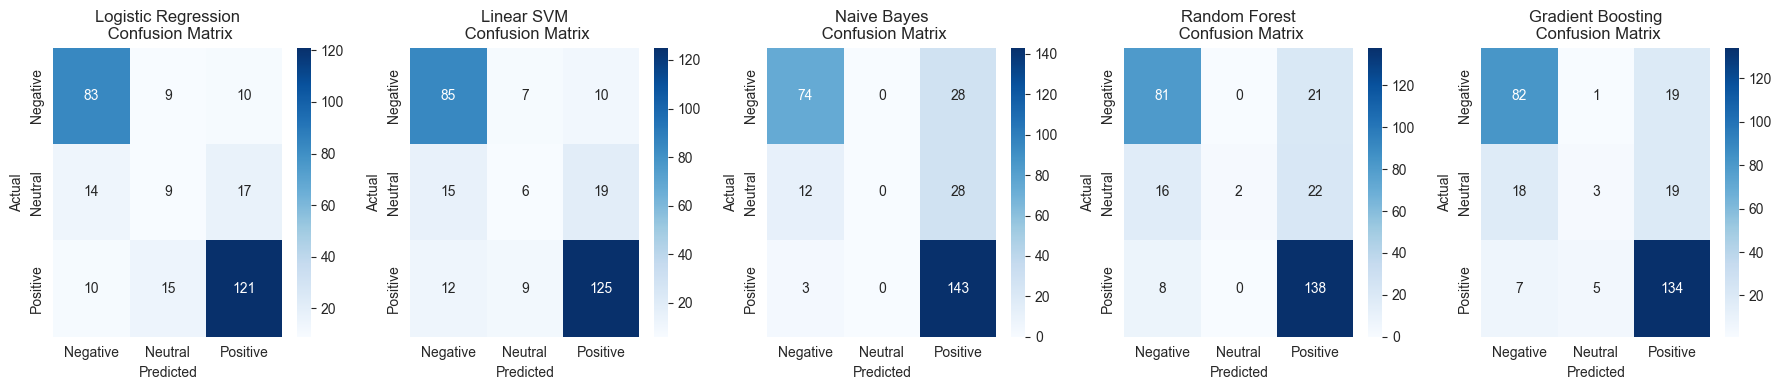

In [22]:
fig, axes = plt.subplots(1,5, figsize=(18,4))
axes= axes.flatten()
order_labels = ['Negative', 'Neutral', 'Positive']
for ax, (name, res) in zip(axes, results.items()):
    cm= confusion_matrix(y_test, res['y_pred'], labels = order_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order_labels, yticklabels=order_labels, ax=ax)
    ax.set_title(f"{name}\n Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

Lexicon based Sentiment Analysis Models

In [23]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text, pos_thresh=0.05, neg_thresh=-0.05):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= pos_thresh:
        return 'Positive'
    elif score <= neg_thresh:
        return 'Negative'
    else:
        return 'Neutral'

raw_text_test = (df.loc[x_test.index, 'title'].astype(str) + ' ' + df.loc[x_test.index, 'body'].astype(str))
y_pred_vader = raw_text_test.apply(vader_sentiment)

vader_acc = accuracy_score(y_test, y_pred_vader)
vader_f1 = f1_score(y_test, y_pred_vader, average='weighted')

print("--- VADER (Lexicon-Based) ---")
print(f"Accuracy: {vader_acc:.4f}   Weighted F1: {vader_f1:.4f}")
print(classification_report(y_test, y_pred_vader))

--- VADER (Lexicon-Based) ---
Accuracy: 0.6910   Weighted F1: 0.6448
              precision    recall  f1-score   support

    Negative       0.73      0.65      0.68       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.70      0.91      0.79       146

    accuracy                           0.69       288
   macro avg       0.48      0.52      0.49       288
weighted avg       0.61      0.69      0.64       288



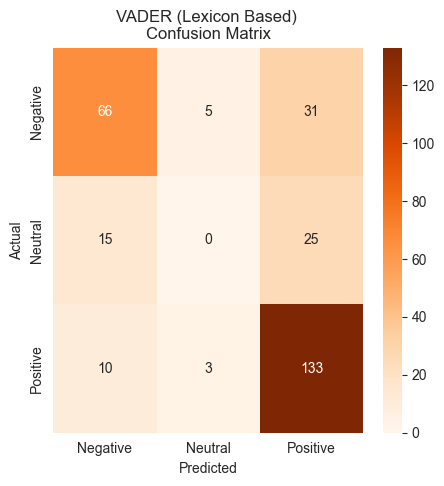

In [24]:
#confusion Matrix for the Lexicon based model

plt.figure(figsize = (5,5))
cm_vader = confusion_matrix(y_test, y_pred_vader, labels = order_labels)
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Oranges', xticklabels=order_labels, yticklabels=order_labels)
plt.title('VADER (Lexicon Based) \nConfusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
#combining ML models with the lexicon based results for the full comparison
eval_df_full = pd.concat([
    eval_df,pd.DataFrame([{'Model': 'VADER(Lexicon)', 'Accuracy': vader_acc, 'weighted_F1': vader_f1}])
], ignore_index=True).sort_values(by='weighted_F1', ascending=False).reset_index(drop=True)

eval_df_full

,Model,Accuracy,weighted_F1
0,Logistic Regression,0.739583,0.732827
1,Linear SVM,0.750000,0.730683
2,Gradient Boosting,0.760417,0.722154
3,Random Forest,0.767361,0.718281
4,Naive Bayes,0.753472,0.694682
5,VADER(Lexicon),0.690972,0.644757


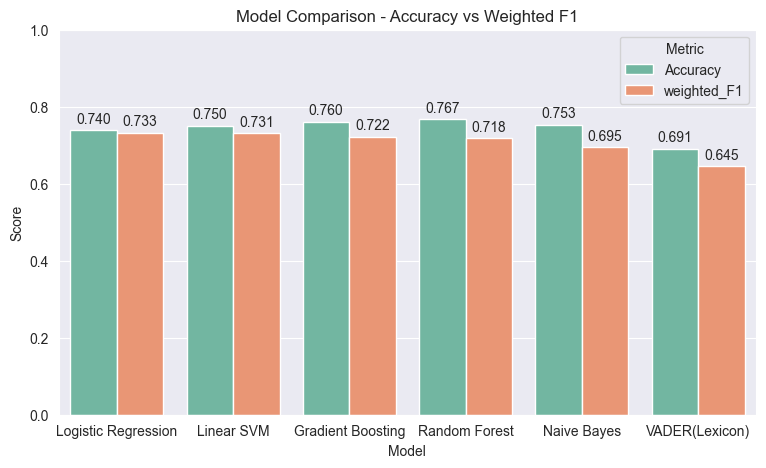

In [26]:
plt.figure(figsize = (9,5))
comp_melt_all = eval_df_full.melt(id_vars='Model', value_vars=['Accuracy', 'weighted_F1'], var_name='Metric', value_name='Score')
ax=sns.barplot(data=comp_melt_all, x='Model', y='Score', hue='Metric', palette='Set2')
for count in ax.containers:
    ax.bar_label(count, fmt='%.3f', padding=3)
plt.title('Model Comparison - Accuracy vs Weighted F1')
plt.ylim(0,1)
plt.show()

Saving Best Model for future use

In [27]:
best_model_name=eval_df_full.iloc[0]['Model']
best_model= results[best_model_name]['model']
print(f"Best Model Selected: {best_model_name}")
print(f"Test Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"Test Weighted F1: {results[best_model_name]['f1']:.4f}")

Best Model Selected: Logistic Regression
Test Accuracy: 0.7396
Test Weighted F1: 0.7328


Creating the PKL Files for Deployment

In [28]:
import pickle
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Saved: sentiment_model.pkl, tfidf_vectorizer.pkl")

Saved: sentiment_model.pkl, tfidf_vectorizer.pkl


Reusable Prediction Fuction

In [29]:
def predict_sentiment(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return pred

# Quick test to see if it works
test_reviews = [
    "This phone is amazing, best camera and battery life!",
    "Worst purchase ever, battery drains in 2 hours and it heats up badly.",
    "It's okay, does the job but nothing special."
]

for r in test_reviews:
    print(f"Review: {r}\nPredicted Sentiment: {predict_sentiment(r)}")
    print()


Review: This phone is amazing, best camera and battery life!
Predicted Sentiment: Positive

Review: Worst purchase ever, battery drains in 2 hours and it heats up badly.
Predicted Sentiment: Negative

Review: It's okay, does the job but nothing special.
Predicted Sentiment: Neutral



In [30]:
appcode='''import streamlit as st
import pickle
import re

# Load the pkl files
model = pickle.load(open('sentiment_model.pkl','rb'))
vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text



st.title("Sentiment Analysis Tool")
user_input = st.text_area("Enter your product review here:")

if st.button("Predict Sentiment"):
    if user_input:
        # Preprocess and predict
        cleaned_input = clean_text(user_input)
        vectorized_input = vectorizer.transform([cleaned_input])
        prediction = model.predict(vectorized_input)

        print(f"User Review :",{user_input})
        st.success(f"The predicted sentiment is: {prediction[0]}")
    else:
        st.warning("Please enter some text.")'''

with open('app.py', 'w', encoding="utf-8") as f:
    f.write(appcode)


print("app.py Generated successfuly")

app.py Generated successfuly
